In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('M:/DataScience/ds_venv/Predict_insurance_charges/insurance.csv')

In [3]:
# Display the first 5 rows to get a quick look at the data
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print("Shape:", df.shape)

Shape: (1338, 7)


In [5]:
# Check column names, data types, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
# Get statistical summary: mean, min, max, std for numeric columns
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


#UNIVARIATE EDA

Analyzing one variable at a time to understand its distribution and spread.

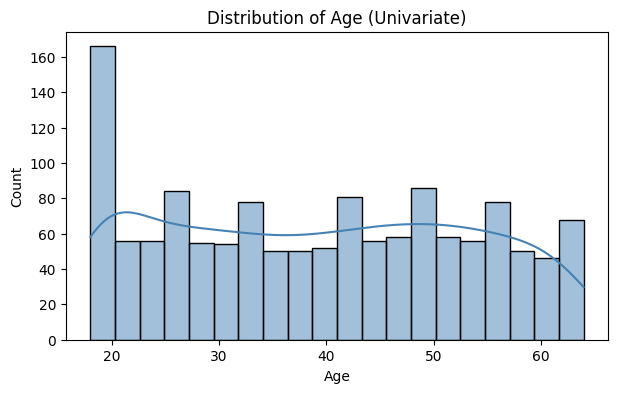

In [7]:
#Univariate: Age Distribution
# Set the figure size for the plot
plt.figure(figsize=(7, 4))
# Draw a histogram of the 'age' column with 20 bins
# kde=True adds a smooth curve showing the distribution shape
sns.histplot(df['age'], bins=20, kde=True, color='steelblue')
# Label the x-axis
plt.xlabel("Age")
# Label the y-axis
plt.ylabel("Count")
# Set the title of the plot
plt.title("Distribution of Age (Univariate)")
# Render the plot
plt.show()

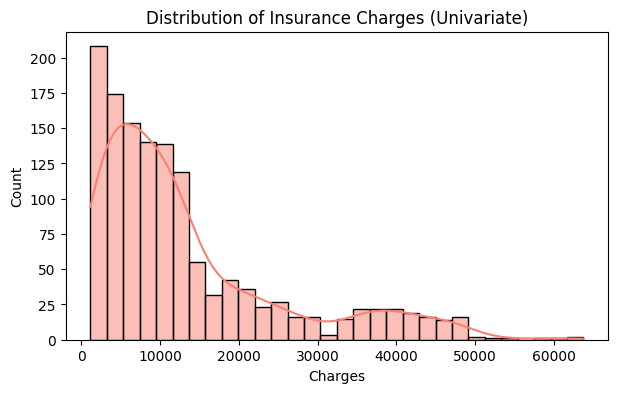

In [8]:
#Univariate: Charges Distribution
plt.figure(figsize=(7, 4))
# Draw histogram for 'charges' — the target variable we want to predict
sns.histplot(df['charges'], bins=30, kde=True, color='salmon')
plt.xlabel("Charges")
plt.ylabel("Count")
plt.title("Distribution of Insurance Charges (Univariate)")
plt.show()

C:\Users\mayur\AppData\Local\Temp\ipykernel_12276\1878242729.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='smoker', data=df, palette='Set2')


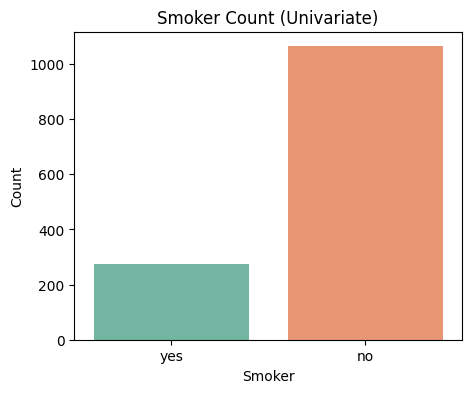

In [9]:
#Univariate: Smoker Count
plt.figure(figsize=(5, 4))

# Draw a count plot for the 'smoker' column (categorical variable)
# This shows how many people are smokers vs non-smokers
sns.countplot(x='smoker', data=df, palette='Set2')

plt.xlabel("Smoker")
plt.ylabel("Count")
plt.title("Smoker Count (Univariate)")
plt.show()

#BIVARIATE EDA

Analyzing two variables together to understand the relationship between them.

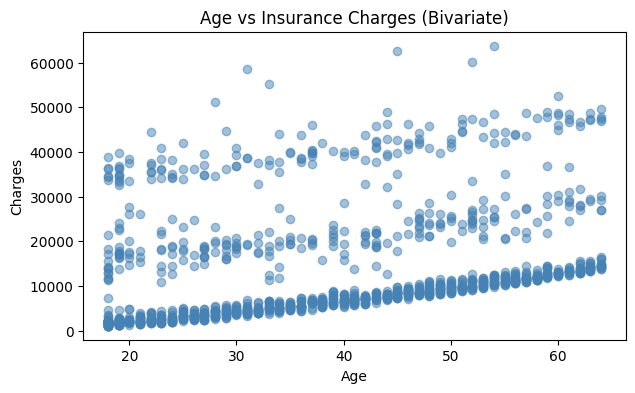

In [10]:
#Bivariate: Age vs Charges (Scatter Plot)
plt.figure(figsize=(7, 4))

# Scatter plot between age (X) and charges (Y)
# Each dot represents one person in the dataset
plt.scatter(df['age'], df['charges'], alpha=0.5, color='steelblue')

# alpha=0.5 makes dots slightly transparent so overlapping points are visible
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Insurance Charges (Bivariate)")
plt.show()

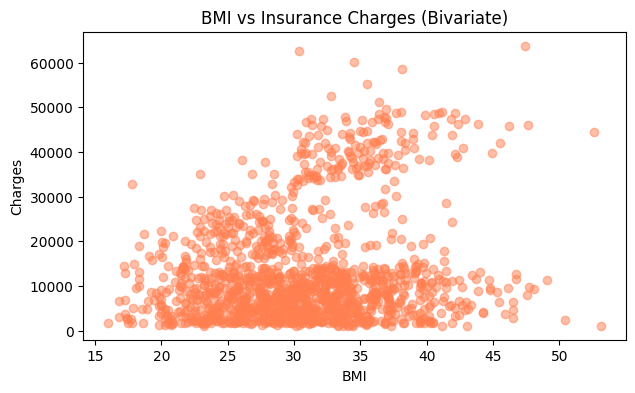

In [11]:
#Bivariate: BMI vs Charges
plt.figure(figsize=(7, 4))

# Scatter plot between BMI (body mass index) and charges
# Helps us see if higher BMI leads to higher charges
plt.scatter(df['bmi'], df['charges'], alpha=0.5, color='coral')

plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("BMI vs Insurance Charges (Bivariate)")
plt.show()

C:\Users\mayur\AppData\Local\Temp\ipykernel_12276\1703740660.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


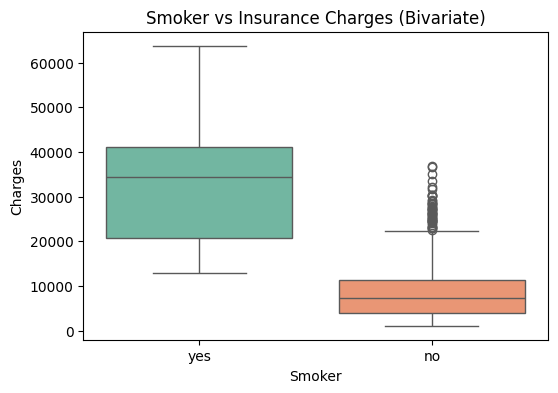

In [12]:
#Bivariate: Smoker vs Charges (Box Plot)
plt.figure(figsize=(6, 4))

# Box plot compares the spread of charges between smokers and non-smokers
# The box shows the middle 50% of data, the line inside is the median
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')

plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.title("Smoker vs Insurance Charges (Bivariate)")
plt.show()

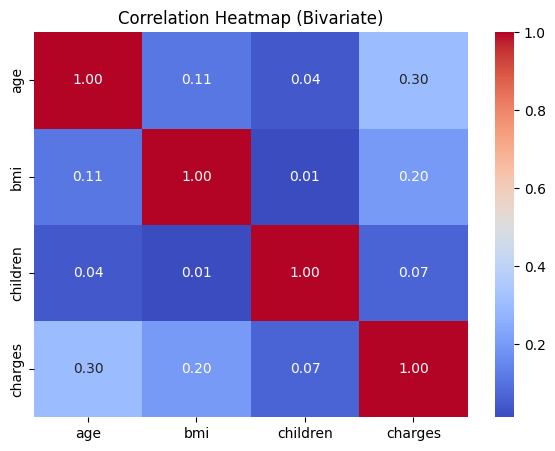

In [13]:
# Bivariate: Correlation Heatmap
plt.figure(figsize=(7, 5))

# Select only numeric columns for correlation calculation
numeric_df = df[['age', 'bmi', 'children', 'charges']]

# corr() computes how strongly each pair of variables is related
# Values close to 1 or -1 = strong relationship, close to 0 = weak
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap (Bivariate)")
plt.show()

#TRIVARIATE EDA

Analyzing three variables together to find deeper patterns.

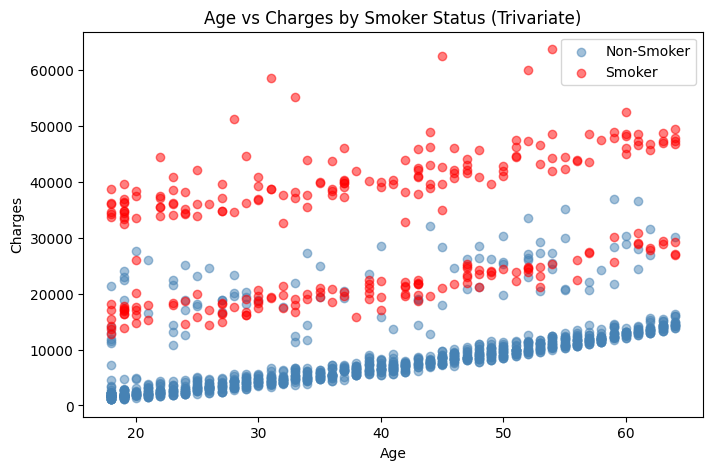

In [14]:
#Trivariate: Age vs Charges, colored by Smoker
plt.figure(figsize=(8, 5))

# Separate data into smokers and non-smokers for different colors
smokers = df[df['smoker'] == 'yes']
non_smokers = df[df['smoker'] == 'no']

# Plot non-smokers in blue
plt.scatter(non_smokers['age'], non_smokers['charges'],
            alpha=0.5, color='steelblue', label='Non-Smoker')

# Plot smokers in red — third variable (smoker) shown through color
plt.scatter(smokers['age'], smokers['charges'],
            alpha=0.5, color='red', label='Smoker')

plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges by Smoker Status (Trivariate)")

# Show legend to identify which color means what
plt.legend()
plt.show()

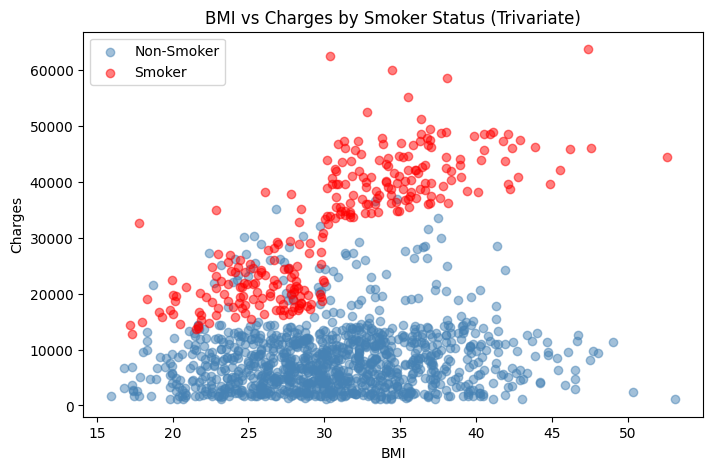

In [15]:
#Trivariate: BMI vs Charges, colored by Smoker
plt.figure(figsize=(8, 5))

# Same idea — BMI on X, charges on Y, smoker status shown by color
plt.scatter(non_smokers['bmi'], non_smokers['charges'],
            alpha=0.5, color='steelblue', label='Non-Smoker')

plt.scatter(smokers['bmi'], smokers['charges'],
            alpha=0.5, color='red', label='Smoker')

plt.xlabel("BMI")
plt.ylabel("Charges")
plt.title("BMI vs Charges by Smoker Status (Trivariate)")
plt.legend()
plt.show()

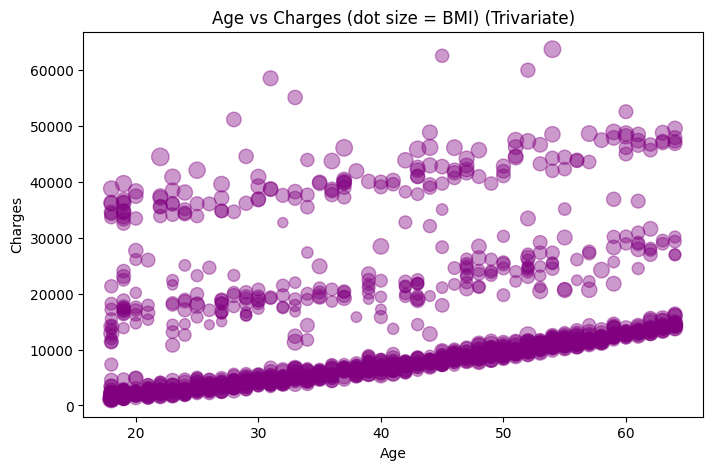

In [16]:
#Trivariate: Age vs Charges, dot size = BMI
plt.figure(figsize=(8, 5))

# Here the third variable (BMI) is represented by the SIZE of each dot
# Larger dot = higher BMI, giving us 3 variables in one plot
plt.scatter(df['age'], df['charges'],
            s=df['bmi'] * 3,   # s controls dot size, multiplied to make it visible
            alpha=0.4, color='purple')

plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges (dot size = BMI) (Trivariate)")
plt.show()

#DATA PREPROCESSING

In [17]:
#Encode Categorical Column
# The 'smoker' column has text values: 'yes' and 'no'
# Machine learning models only understand numbers, not text
# So we convert 'yes' to 1 and 'no' to 0 using map()
df['smoker_encoded'] = df['smoker'].map({'yes': 1, 'no': 0})

# Verify the new column looks correct
df[['smoker', 'smoker_encoded']].head()

,smoker,smoker_encoded
0,yes,1
1,no,0
2,no,0
3,no,0
4,no,0


#MODELING

In [18]:
#Define X and y
# X is the input feature (independent variable) — what we feed into the model
# We use double brackets [[]] because sklearn expects a 2D array for X
X = df[['age']]

# y is the output (dependent variable) — what we want the model to predict
y = df['charges']

In [19]:
#Train/Test Split
# Import the function that splits data into training and testing sets
from sklearn.model_selection import train_test_split

# Split the data:
# - 80% goes to training (model learns from this)
# - 20% goes to testing (model is evaluated on this, unseen data)
# random_state=42 ensures the split is the same every time you run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print sizes to confirm the split
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (1070, 1)
Testing size: (268, 1)


In [20]:
#Train the Model
# Import the Linear Regression model from sklearn
from sklearn.linear_model import LinearRegression

# Create an instance of the LinearRegression model
model = LinearRegression()

# Train (fit) the model using the training data
# The model learns the best slope and intercept from X_train and y_train
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [21]:
# Model Parameters
# intercept_ is the value of y when x = 0 (the starting point of the line)
print("Intercept (b0):", model.intercept_)

# coef_ is the slope — how much charges increase for every 1 year increase in age
print("Slope (b1):", model.coef_[0])

# This gives us the regression equation:
# Charges = b0 + b1 * Age
print("\nRegression Equation:")
print(f"Charges = {model.intercept_:.2f} + {model.coef_[0]:.2f} * Age")

Intercept (b0): 3876.928684191691
Slope (b1): 240.59655978877493

Regression Equation:
Charges = 3876.93 + 240.60 * Age


#PREDICTION

In [22]:
#Predict on Test Data
# Use the trained model to predict charges for the test set
# The model uses the regression equation it learned during training
y_pred = model.predict(X_test)

# Build a comparison table to see actual vs predicted side by side
comparison = pd.DataFrame({
    "Age": X_test["age"],           # the input age values
    "Actual Charges": y_test,        # the real charges from the dataset
    "Predicted Charges": y_pred      # what our model predicted
})

# Reset index so the table looks clean
comparison = comparison.reset_index(drop=True)

# Display the table
comparison.head(10)

,Age,Actual Charges,Predicted Charges
0,45,9095.06825,14703.773875
1,36,5272.17580,12538.404837
2,64,29330.98315,19275.108511
3,46,9301.89355,14944.370434
4,19,33750.29180,8448.263320
5,34,4536.25900,12057.211717
6,19,2117.33885,8448.263320
7,64,14210.53595,19275.108511
8,28,3732.62510,10613.632358
9,49,10264.44210,15666.160114


In [23]:
# Create a new input as a DataFrame with the column name the model was trained on
new_age = pd.DataFrame({'age': [25]})

# Pass it through the model to get a predicted charge
predicted = model.predict(new_age)

# Print the result
print(f"Predicted insurance charge for age 25: ₹{predicted[0]:.2f}")

Predicted insurance charge for age 25: ₹9891.84


#MODEL EVALUATION

In [24]:
# Import the evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# MAE — Mean Absolute Error
# Average of how far off each prediction is from the actual value
# Lower is better
mae = mean_absolute_error(y_test, y_pred)

# MSE — Mean Squared Error
# Like MAE but squares the errors, so big mistakes are penalized more
# Lower is better
mse = mean_squared_error(y_test, y_pred)

# RMSE — Root Mean Squared Error
# Square root of MSE, brings error back to the same unit as charges
rmse = np.sqrt(mse)

# R² Score — tells how much of the variation in charges is explained by age
# Ranges from 0 to 1: closer to 1 = better fit
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 9173.26
MSE  : 135983957.48
RMSE : 11661.22
R²   : 0.1241


#VISUALIZATION

M:\DataScience\ds_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


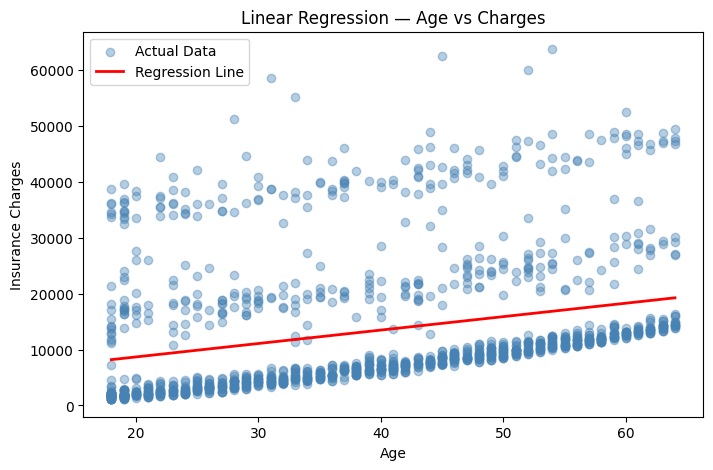

In [25]:
#Regression Line on Full Dataset
plt.figure(figsize=(8, 5))

# Plot all actual data points as a scatter plot
plt.scatter(df['age'], df['charges'], alpha=0.4, color='steelblue', label='Actual Data')

# Generate a range of age values from min to max to draw a smooth line
age_range = np.linspace(df['age'].min(), df['age'].max(), 100).reshape(-1, 1)

# Predict charges for each age in the range using the trained model
predicted_line = model.predict(age_range)

# Plot the regression line in red
plt.plot(age_range, predicted_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Linear Regression — Age vs Charges")
plt.legend()
plt.show()

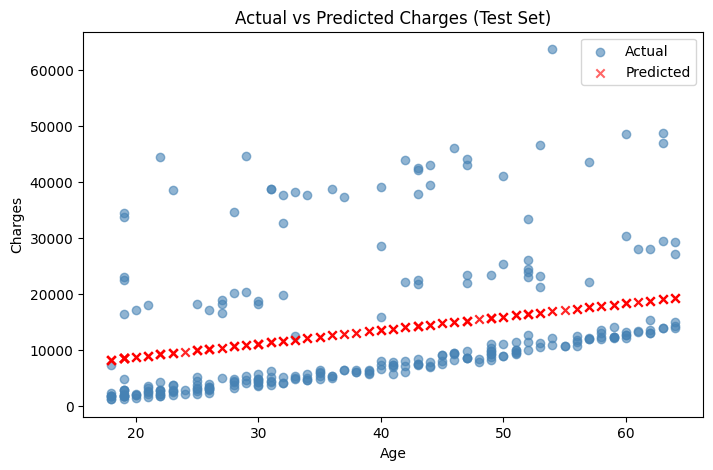

In [26]:
#Actual vs Predicted (Test Set)
plt.figure(figsize=(8, 5))

# Plot actual charges from test set
plt.scatter(X_test, y_test, alpha=0.6, color='steelblue', label='Actual')

# Plot predicted charges from test set
plt.scatter(X_test, y_pred, alpha=0.6, color='red', marker='x', label='Predicted')

plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Actual vs Predicted Charges (Test Set)")
plt.legend()
plt.show()

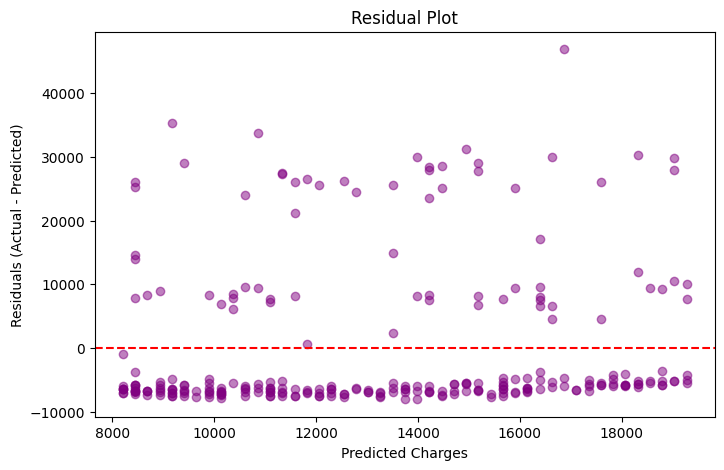

In [27]:
#Residual Plot
# Residuals = the difference between actual and predicted values
# If the model is good, residuals should be randomly scattered around 0
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

# Plot residuals against predicted values
# A random scatter with no pattern means the model assumptions are valid
plt.scatter(y_pred, residuals, alpha=0.5, color='purple')

# Draw a horizontal red line at 0 for reference
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

#INTERPRETATION

In [28]:
#Summary Text Block
print("=" * 50)
print("MODEL INTERPRETATION SUMMARY")
print("=" * 50)
print(f"Intercept (b0)   : {model.intercept_:.2f}")
print(f"Slope     (b1)   : {model.coef_[0]:.2f}")
print(f"R² Score         : {r2:.4f}")
print(f"MAE              : {mae:.2f}")
print(f"RMSE             : {rmse:.2f}")
print("=" * 50)
print("\nInterpretation:")
print(f"- For every 1 year increase in age, insurance charges increase by ₹{model.coef_[0]:.2f}")
print(f"- The model explains {r2*100:.2f}% of the variance in charges")
print(f"- On average, predictions are off by ₹{mae:.2f}")
print("- R² is low because 'age' alone doesn't fully explain charges.")
print("  Smoker status and BMI are also major factors.")

MODEL INTERPRETATION SUMMARY
Intercept (b0)   : 3876.93
Slope     (b1)   : 240.60
R² Score         : 0.1241
MAE              : 9173.26
RMSE             : 11661.22

Interpretation:
- For every 1 year increase in age, insurance charges increase by ₹240.60
- The model explains 12.41% of the variance in charges
- On average, predictions are off by ₹9173.26
- R² is low because 'age' alone doesn't fully explain charges.
  Smoker status and BMI are also major factors.
